In [149]:
# pandas / matplotlib / seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [245]:
X = pd.read_csv('titanic_X.csv')
y = pd.read_csv('titanic_y.csv')
train = pd.concat([X, y], axis=1)
# train
# train = pd.read_csv('data/train.csv')
# test
# test = pd.read_csv('data/test.csv')
# gender
# gender = pd.read_csv('data/gender_submission.csv')

In [5]:
train.columns

Index(['pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare',
       'cabin', 'embarked', 'boat', 'body', 'home.dest', 'survived'],
      dtype='object')

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   name       1309 non-null   object 
 2   sex        1309 non-null   object 
 3   age        1046 non-null   float64
 4   sibsp      1309 non-null   int64  
 5   parch      1309 non-null   int64  
 6   ticket     1309 non-null   object 
 7   fare       1308 non-null   float64
 8   cabin      295 non-null    object 
 9   embarked   1307 non-null   object 
 10  boat       486 non-null    object 
 11  body       121 non-null    float64
 12  home.dest  745 non-null    object 
 13  survived   1309 non-null   int64  
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


In [137]:
# 결측치 확인
train.isnull().sum()

pclass          0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
survived        0
dtype: int64

In [9]:
# %pip install missingno

Note: you may need to restart the kernel to use updated packages.


<Axes: >

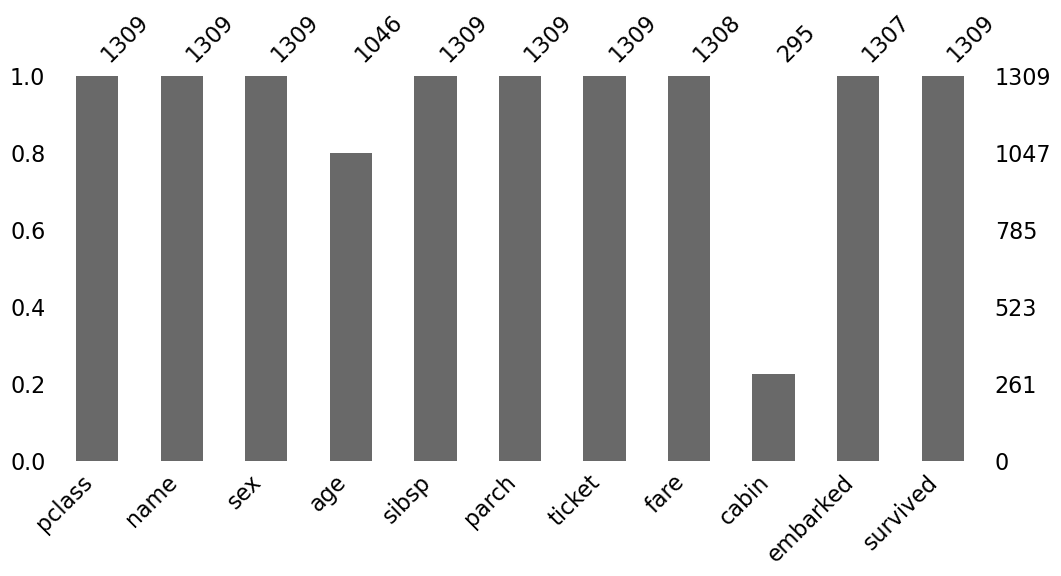

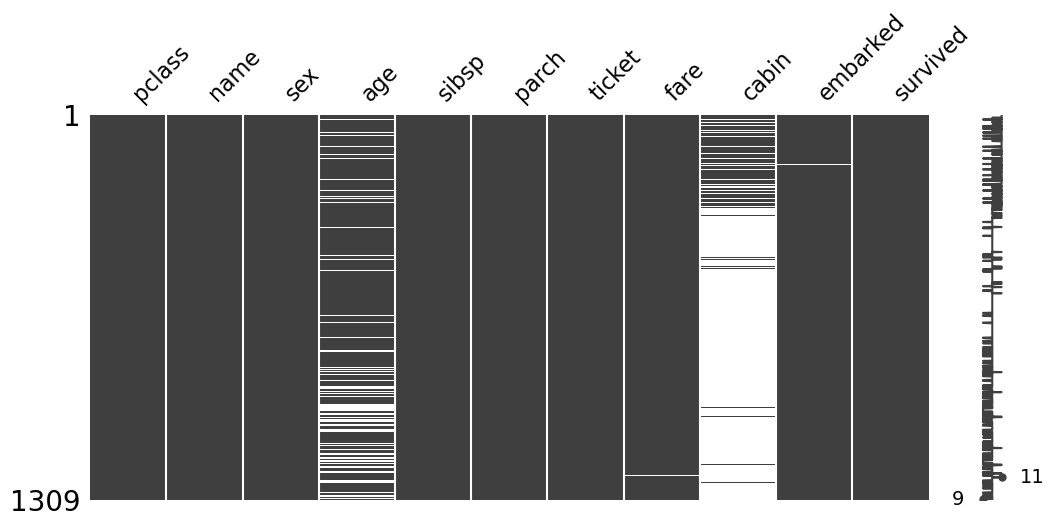

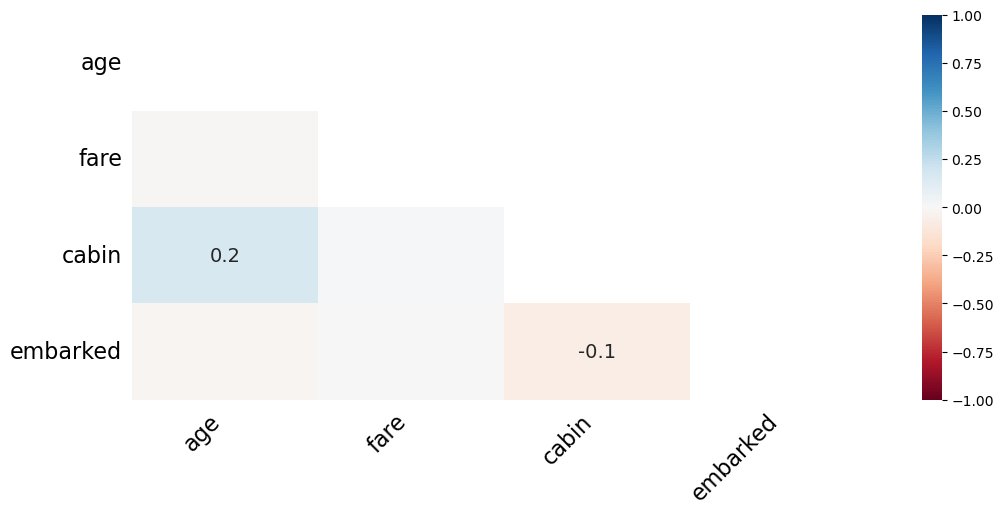

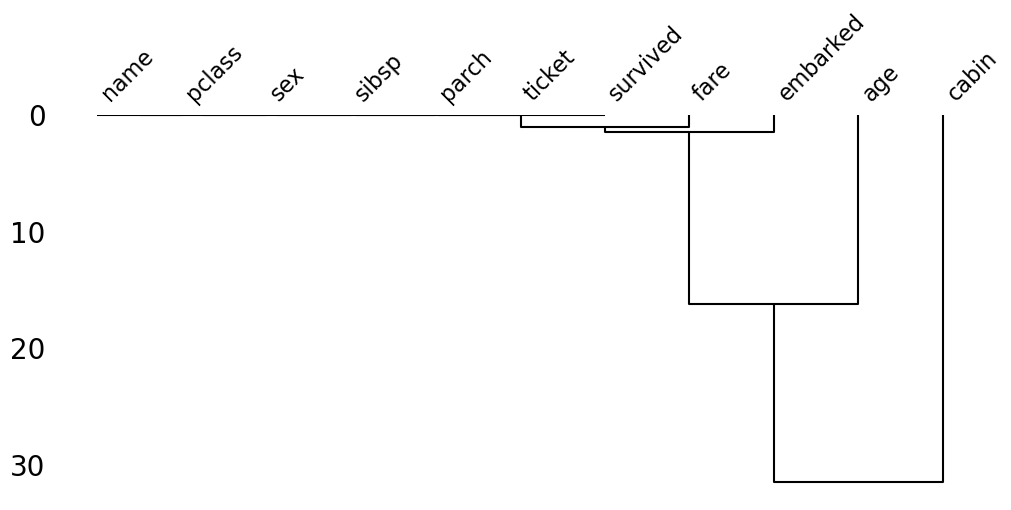

In [13]:
import missingno as msno
msno.bar(train, figsize=(12,5))
msno.matrix(train, figsize=(12,5))
msno.heatmap(train, figsize=(12,5))
msno.dendrogram(train, figsize=(12,5))

### 생존

<Axes: ylabel='count'>

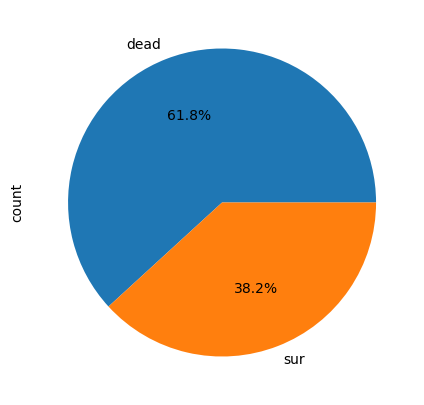

In [15]:
# 생존비율 확인
# train에서 생존과 사망이 어떤 비율로 있는지 확인
# 생존에 관련된 데이터은 어디에 담겨있나요?
# value_counts : 컬럼에 있는 유니크한 내용에 수를 카운트 하는 함수
# 여기서는 뭐랑 뭐만 카운트가 될까요?? / dead survived만 카운트가 되겠죠??
train['survived'].value_counts()

plt.figure(figsize=(8,5))
labels = ['dead','sur']
# 파이 차트를 사용
train['survived'].value_counts().plot.pie(autopct='%1.1f%%',
                                         labels = labels)

### 이 그래프를 통해 알 수 있는 사실은 사망 비율은 약 61% 생존 비율은 약 39%로 사망한 탑승 객의 수가 더 많은 것이 확인된다

### 성별

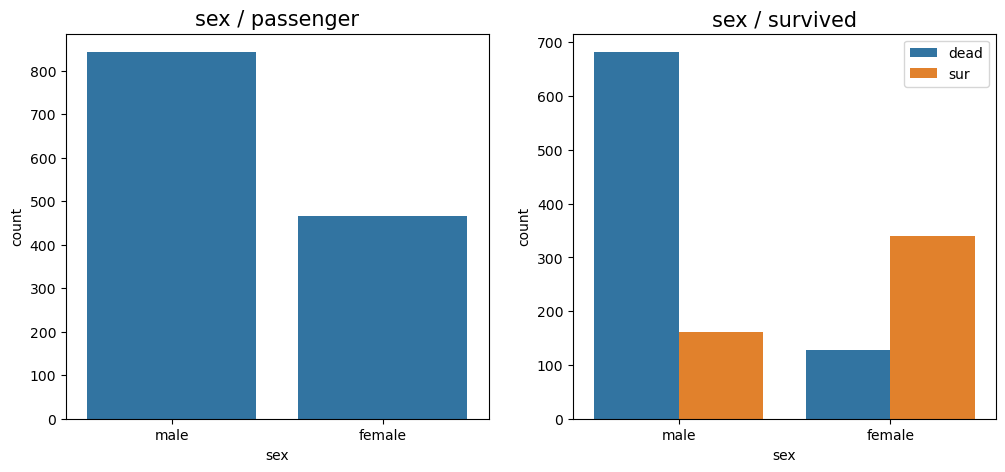

In [27]:
# fit, axes : 변수 2개를 지정한 이유 -> 행과 열에 대한 내용입니다
# 그럼 지금 이 subplots의 의미는 한 행에 박스 2개 만들겠다는 의미겠죠??
fit, axes = plt.subplots(1,2,figsize=(12,5))
# 첫번째 박스에 관련된 내용
# 인덱스 번호 0 처음을 의미
# 항상 시각화를 할 때 맨 처음에 들어오는 데이터는 어떤 축이라고 했어요??
# X축을 먼저 지정한다
axes[0].set_title('sex / passenger', size = 15)
# order -> 'male'을 먼저, 'female'을 나중에 그리라고 명시!
sns.countplot(x = 'sex', data = train, ax = axes[0], order=['male', 'female'])

# axes[1] 두번째 박스
axes[1].set_title('sex / survived', size = 15)
# hue_order -> 0(사망)이 왼쪽, 1(생존)이 오른쪽 색상으로 고정
sns.countplot(x='sex', hue = 'survived', data = train, \
              ax = axes[1], order=['male', 'female'], hue_order=[0, 1])
axes[1].legend(labels = ['dead','sur'])

### 이 시각화를 통해 알 수 있는 사실은 타이타닉 호에 남성이 더 많이 타 있었지만 여성이 더 많이 살았다 

,survived
sex,
female,0.727468
male,0.190985


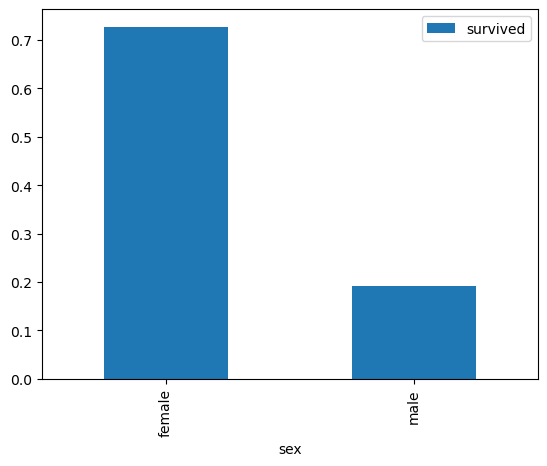

In [33]:
# 성별에 따른 생존률도 한번 보도록 하겠습니다
# 대괄호 2개 입니다
# 성별로 그룹화 시켜주겠다
sur = train[['sex','survived']].groupby('sex').mean().plot.bar()
train[['sex','survived']].groupby('sex').mean()

### 여성의 생존률은 약 74% 남성의 생존률은 약 18%로 여성의 생존률이 압도적으로 높은걸 확인할 수 있다
- 남성보다 여성을 먼저 구조한 것으로 보인다

# 티켓 클라스(pclass)

,count,sum
pclass,,
1,323,200
2,277,119
3,709,181


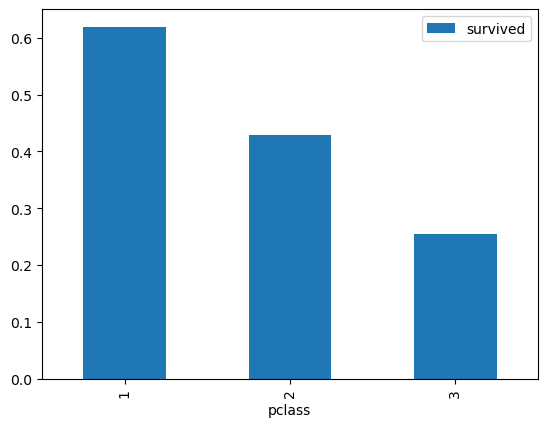

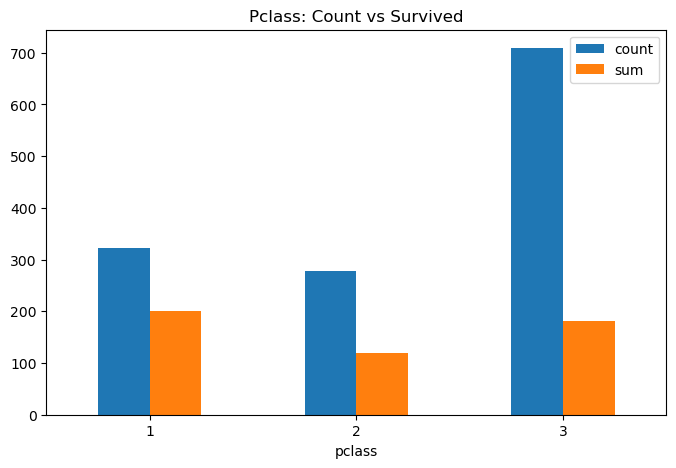

In [55]:
# 티켓 클래스 별로 어떤 생존률을 보이고 있는지 확인
train[['pclass','survived']].groupby('pclass').mean().plot.bar()
# 클래스별 인원수와 클래스별 생존자수
train.groupby('pclass')['survived'].agg(['count', 'sum'])\
    .plot.bar(figsize=(8, 5), rot=0, title='Pclass: Count vs Survived')
train.groupby('pclass')['survived'].agg(['count', 'sum'])

### 1등석의 생존률은 약 62% 2등석의 생존률은 약 47% 3등석의 생존률은 약 24%로 확인된다
- 그렇다는 말은 3등석 탑승객들이 많이 사망했다라고 생각해도 되지 않을까??

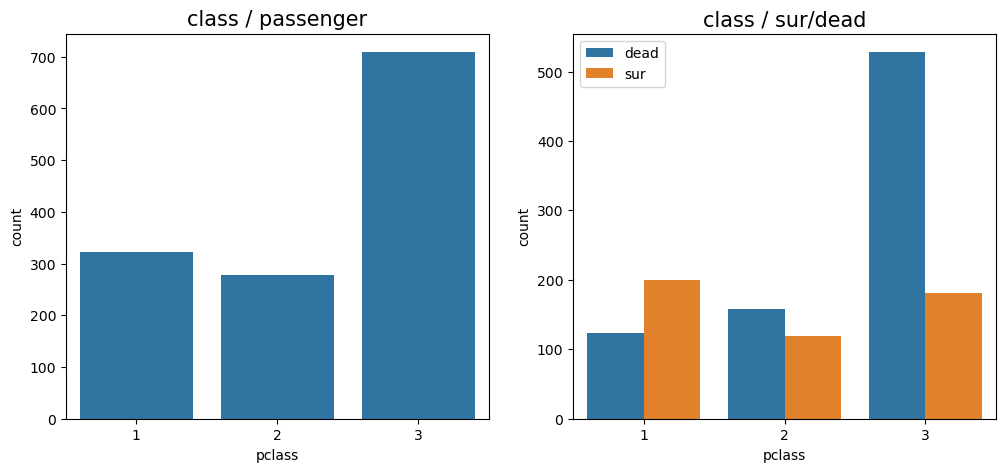

In [56]:
# 시각화해서 살펴보자
fig, axes = plt.subplots(1,2,figsize=(12,5))

# 첫번째 박스
axes[0].set_title('class / passenger', size = 15)
sns.countplot(x = 'pclass', data = train, ax = axes[0])

# 두번째 박스
axes[1].set_title('class / sur/dead', size = 15)
sns.countplot(x = 'pclass', data = train, hue = 'survived', ax = axes[1])
axes[1].legend(labels = ['dead','sur'])

### 3등석 탑승객이 가장 많고 3등석 탑승객의 사망 인원수 또한 가장 많은 걸 확인할 수 있다 상대적으로 1등석 탑승객들은 많이 살아남은 것으로 보인다

Text(0.5, 1.0, 'class / sur')

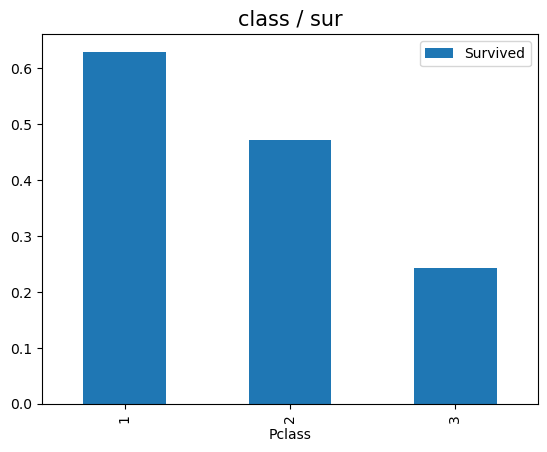

In [21]:
# 클래스별 생존률을 확인해보면
sur = train[['Pclass','Survived']].groupby(['Pclass']).mean().plot.bar()
sur.set_title('class / sur', size = 15)

### 1등석이 가장 높은 생존률을 보이고 3등석이 가장 낮은 생존률을 보인다 class는 생존 유무에 어느 정도 영향을 미치는 것으로 보인다

### 나이(age)

In [57]:
# 수치적으로 어떻게 분포되었는지 확인
train['age'].describe()

count    1046.000000
mean       29.881135
std        14.413500
min         0.166700
25%        21.000000
50%        28.000000
75%        39.000000
max        80.000000
Name: age, dtype: float64

<Axes: xlabel='age', ylabel='Count'>

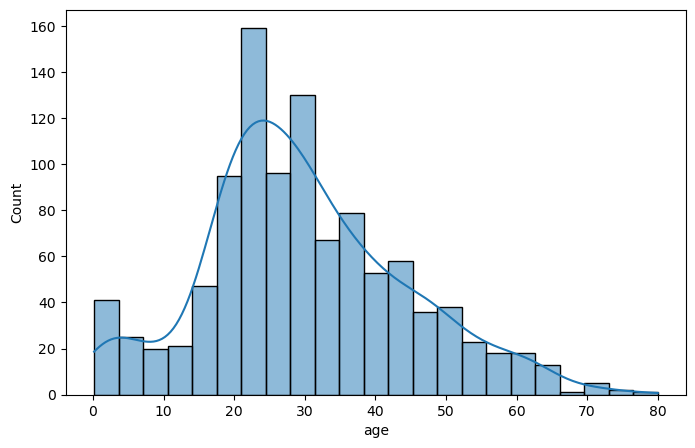

In [66]:
# figsize = 박스 그래프가 나오는 크기의 사이즈 지정
# 사용자가 지정하므로 정확한 정답이 없다
# distplot 히스토그램 + 곡선그래프
plt.figure(figsize=(8,5))
# sns.distplot(train['age'], bins = 25)
# sns.histplot(train['age'], kde=True, stat="density")
sns.histplot(train['age'], kde=True)

### 탑승객의 나이는 주로 10 or 20 ~ 40 or 50 까지 분포하고 있다

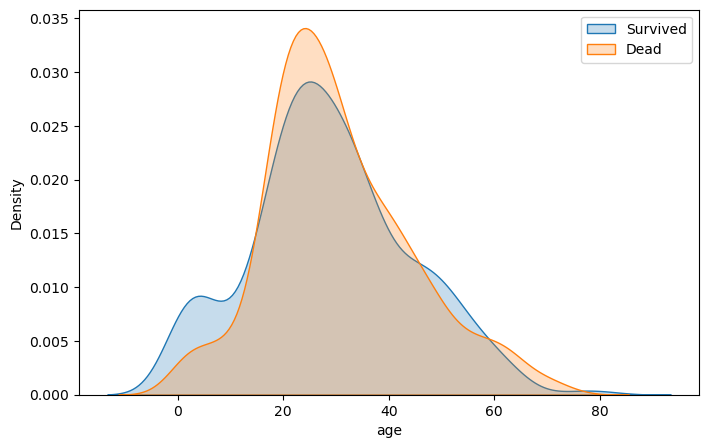

In [81]:
# 나이가 생존여부에 영향을 끼치는지 확인하기 위해
# 생존/사망 탑승객을 나눠보겠다

# sur = train[train['survived'] == 1]
# dead = train[train['survived'] == 0]

# plt.figure(figsize=(8,5))
# sns.distplot(sur['age'], bins = 25, hist = False)
# sns.distplot(dead['age'], bins = 25, hist = False)
# plt.legend()
# plt.show()

plt.figure(figsize=(8, 5))

# shade 대신 fill을 사용하세요!
sns.kdeplot(train.loc[train['survived'] == 1, 'age'], label='Survived', fill=True)
sns.kdeplot(train.loc[train['survived'] == 0, 'age'], label='Dead', fill=True)

plt.legend()
plt.show()

### 어린 나이의 탑승객들의 생존률이 비교적 높고 20~30세의 죽음이 많았다

 SibSp -> 함께 탑승한 형제자매, 배우자의 수 총합 <br>
 Parch -> 함께 탑승한 부모, 자녀 수 총합

In [30]:
# 함께 탑승한 형제나 배우자 또는 부모와 생존이 관련있는지 확인
# SibSp / Parch 가족의 수와 비슷하므로 비슷한 경향을 것 같다

<Axes: title={'center': 'parch / survived'}, xlabel='parch', ylabel='count'>

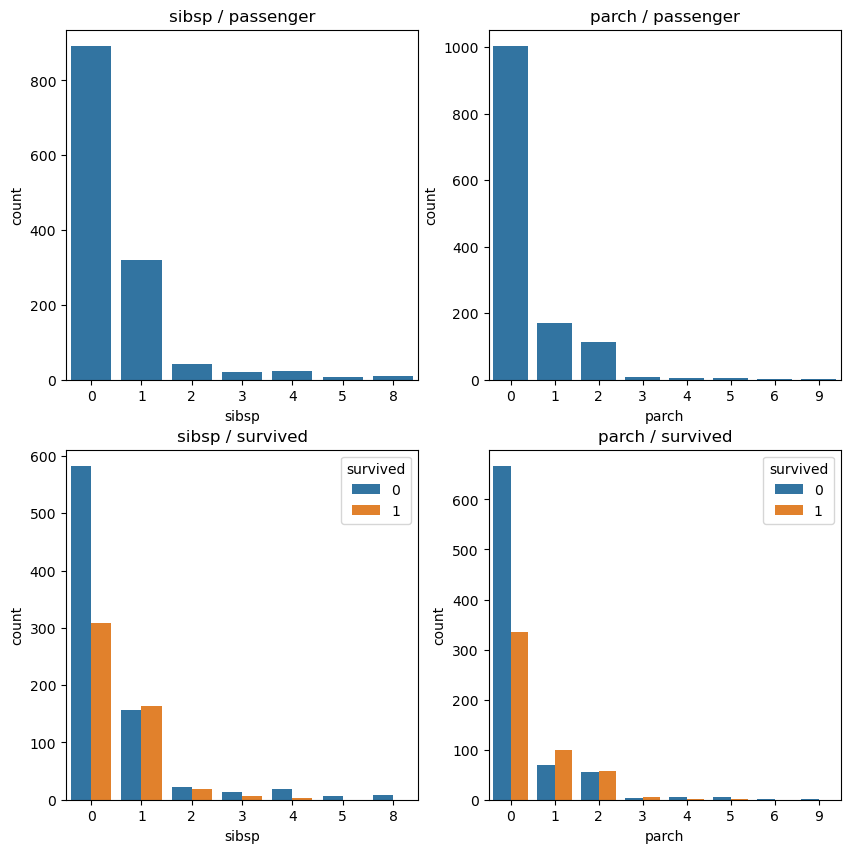

In [90]:
# 이번엔 2 * 2 상자를 만들어서 그래프를 그릴껀데
# 코드상 2 * 2 상자를 한 번 만들어보세요 변수도 생각하셔야 합니다

# 첫번째 박스 [0][0]
fig, axes = plt.subplots(2,2,figsize=(10,10))
axes[0][0].set_title('sibsp / passenger', size = 12)
sns.countplot(x = 'sibsp', data = train, ax = axes[0][0])

# 두번째 박스 [0][1]
axes[0][1].set_title('parch / passenger', size = 12)
sns.countplot(x = 'parch', data = train, ax = axes[0][1])

# 세번째 박스 [1][0]
axes[1][0].set_title('sibsp / survived', size = 12)
sns.countplot(x = 'sibsp', data = train, hue = 'survived',ax = axes[1][0])

# 네번째 박스 [1][1]
axes[1][1].set_title('parch / survived', size = 12)
sns.countplot(x = 'parch', data = train, hue = 'survived',ax = axes[1][1])

# SibSp -> 함께 탑승한 형제자매, 배우자의 수 총합 
# Parch -> 함께 탑승한 부모, 자녀 수 총합

### 혼자 탑승한 탑승객이 많다
### 생존 여부를 확인해보면 혼자 탑승한 사람들이 많이 사망한 걸 확인할 수 있다

In [33]:
# 실제로 SibSp Parch별로 생존률을 확인해보자

In [91]:
print(train[['sibsp','survived']].groupby(['sibsp']).mean())
print(train[['parch','survived']].groupby(['parch']).mean())

       survived
sibsp          
0      0.346801
1      0.510972
2      0.452381
3      0.300000
4      0.136364
5      0.000000
8      0.000000
       survived
parch          
0      0.335329
1      0.588235
2      0.504425
3      0.625000
4      0.166667
5      0.166667
6      0.000000
9      0.000000


### 수치적으로 봤을 때 혼자 탑승한 승객의 살 확률이 30% 이며 1~2명 같이 온 사람들의 생존확률이 50% 언저리 인 걸 확인할 수 있다

# 탑승항구

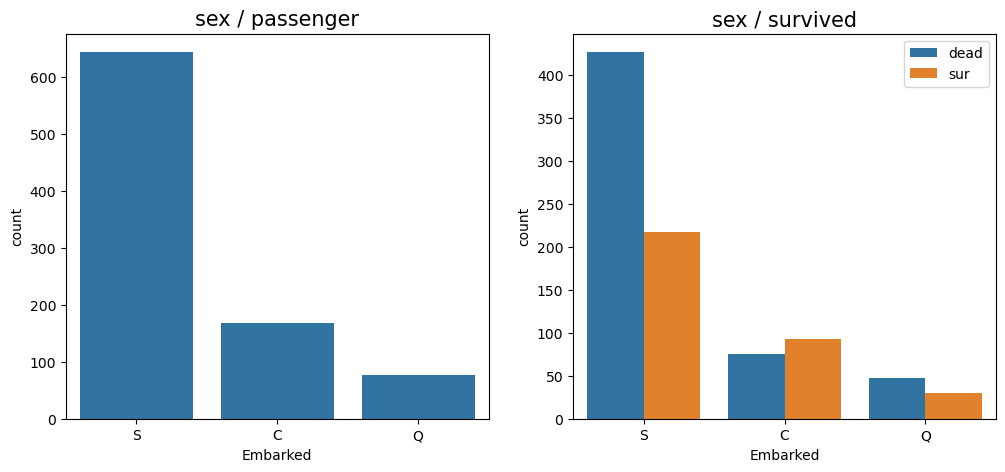

In [37]:
fig, axes = plt.subplots(1,2,figsize=(12,5))

axes[0].set_title('sex / passenger', size = 15)
sns.countplot(x = 'Embarked', data = train, ax = axes[0])

axes[1].set_title('sex / survived', size = 15)
sns.countplot(x = 'Embarked',hue = 'Survived',data = train, ax = axes[1])
axes[1].legend(labels = ['dead','sur'])

### s항구 탑승객이 가장 많은 인원 분포를 가지고 있으며 사망한 인원도 s항구 탑승객이 많다

In [39]:
# 그럼 항구별 사망 비율을 한번 만들어보세요!!
train[['Embarked','Survived']].groupby(['Embarked']).mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


### 항구별로 사망률에 차이가 왜 나는지 확인하기 위해 항구별 탑승객의 티켓 클래스와 동승자 확인해보자

<Axes: >

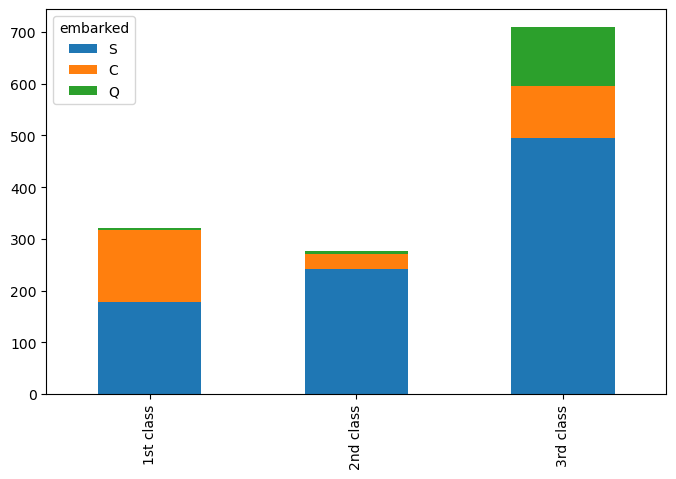

In [92]:
pc1= train[train['pclass'] == 1]['embarked'].value_counts()
pc2= train[train['pclass'] == 2]['embarked'].value_counts()
pc3= train[train['pclass'] == 3]['embarked'].value_counts()

# pc라는 변수에 pc1,pc2,pc3를 데이터 프레임으로 만들어보자
pc = pd.DataFrame([pc1,pc2,pc3])

pc.index = ['1st class','2nd class','3rd class']

# 시각화 해서보면
fig, ax = plt.subplots(figsize = (8,5))
pc.plot(kind = 'bar', stacked = True, ax = ax)

### 3등석(이코노미)에 s항구 탑승객이 주로 분포하고 있는 걸 확인
### 3등석이 배의 하부에 가장 근접했고 class에 따라 생존 확률이 달라지는 걸 확인할 수 있다

### 항구별 탑승객들의 동승자

<Axes: xlabel='parch', ylabel='count'>

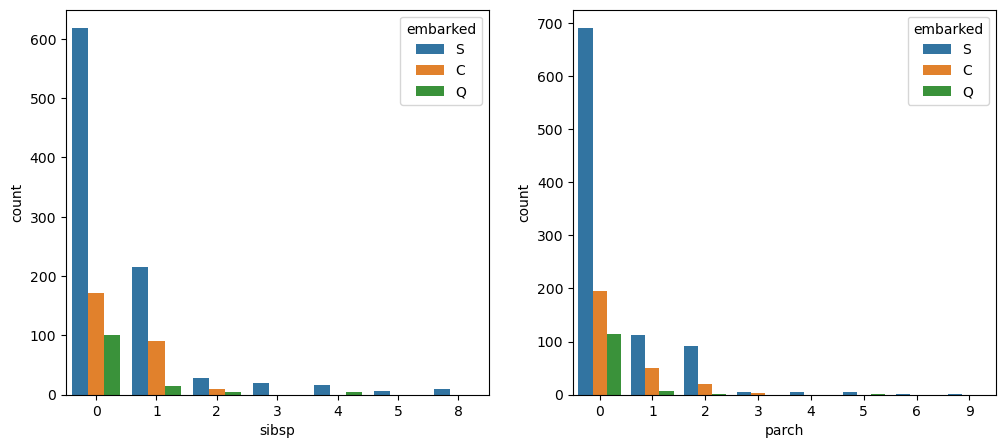

In [93]:
# 항구별 탑승객 동승자에 대해서 알아보도록 하겠습니다
# SibSp, Parch 데이터를 활용해서 확인

fig, ax = plt.subplots(1,2,figsize=(12,5))
sns.countplot(x='sibsp', data = train, hue = 'embarked', ax = ax[0])
sns.countplot(x='parch', data = train, hue = 'embarked', ax = ax[1])

### 혼자 탑승한 탑승객의 수는 S항구에서 탑승객이 압도적으로 많다는 걸 알 수 있다

# Fare(탑승 금액)

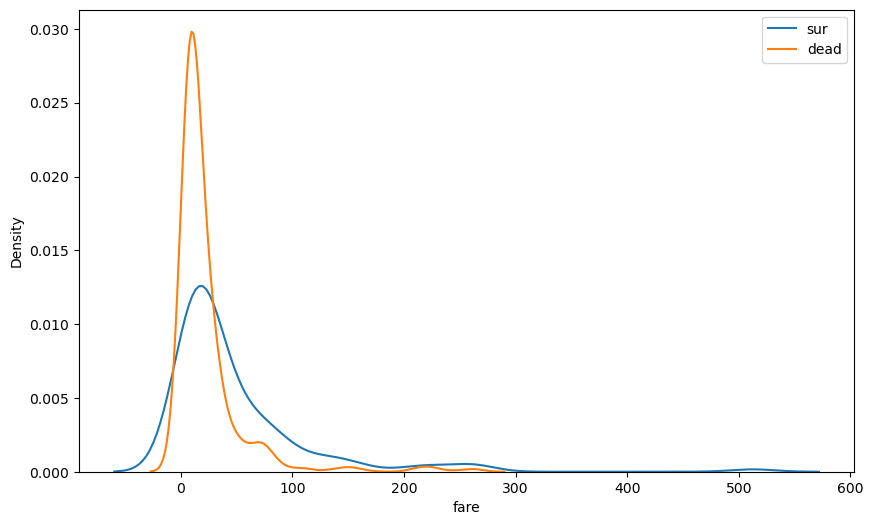

In [105]:
# 탑승 금액의 분포를 확인
fig, ax = plt.subplots(figsize=(10,6))
sns.kdeplot(train[train['survived'] == 1]['fare'], ax = ax)
sns.kdeplot(train[train['survived'] == 0]['fare'], ax = ax)
ax.legend(labels = ['sur', 'dead'])

### 이 그래프에서 알 수 있는 사실
### 탑승 금액이 적은 쪽은 사망률이 높아 보인다
### 탑승 class / 탑승 금액에 따라 생존 여부에 영향일 미치는 것 같다

### 이번 시간에는 파악한 정보를 토대로 전처리를 진행해보자

In [165]:
# 다시 한 번 결측치 확인
train.isnull().sum()

pclass              0
name                0
sex                 0
age                 0
sibsp               0
parch               0
ticket              0
fare                0
cabin            1014
embarked            0
boat              823
body             1188
home.dest         564
survived            0
Surname             0
Group               0
FamilySize          0
IsAlone             0
GroupSurvival       0
Title               0
Age_scaled          0
Fare_scaled         0
Age_Group           0
dtype: int64

In [116]:
train['name']

0                         Allen, Miss. Elisabeth Walton
1                        Allison, Master. Hudson Trevor
2                          Allison, Miss. Helen Loraine
3                  Allison, Mr. Hudson Joshua Creighton
4       Allison, Mrs. Hudson J C (Bessie Waldo Daniels)
                             ...                       
1304                               Zabour, Miss. Hileni
1305                              Zabour, Miss. Thamine
1306                          Zakarian, Mr. Mapriededer
1307                                Zakarian, Mr. Ortin
1308                                 Zimmerman, Mr. Leo
Name: name, Length: 1309, dtype: object

In [246]:
# 이름에서 성씨(Surname) 추출 
# 가족을 묶기 위해 '이름' 자체가 아닌 '성(Family Name)'이 필요합니다.
train['Surname'] = train['name'].str.extract('([A-Za-z]+),', expand=False)

# 가족 그룹(Group) 식별하기
# 같은 티켓 번호를 가졌거나, 같은 성씨를 가진 사람들을 하나의 '가족/일행'으로 정의합니다.
train['Group'] = train['ticket'].astype(str) + train['Surname']

# 가족 수
train["FamilySize"] = train["sibsp"] + train["parch"] + 1

# 혼자인지 여부
train["IsAlone"] = 1
train.loc[train["FamilySize"] > 1, "IsAlone"] = 0

# ★고득점의 핵심: Group Survival 로직★
# "가족 중 누군가 살았다면 나도 살 확률이 높다"는 규칙을 수치화합니다.
# 본인을 제외한 나머지 가족 구성원의 생존 여부 평균을 구합니다.
train['GroupSurvival'] = 0.5 # 일단 기본값은 0.5(모름)로 설정

for grp, grp_df in train.groupby('Group'):
    if len(grp_df) > 1: # 혼자가 아닌 일행이 있는 경우만 계산
        for ind, row in grp_df.iterrows():
            # 나를 제외한 나머지 일행들의 생존율 합계
            all_minus_me = grp_df.drop(ind)['survived']
            if all_minus_me.max() == 1.0: # 일행 중 한 명이라도 살았다면
                train.loc[ind, 'GroupSurvival'] = 1.0
            elif all_minus_me.min() == 0.0: # 일행 중 한 명이라도 죽었다면
                train.loc[ind, 'GroupSurvival'] = 0.0

In [247]:
# 칭호(Title) 추출 및 전처리
train['Title'] = train['name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# train['Title'] = train['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
# train['Title'] = train['Title'].replace(['Mlle', 'Ms'], 'Miss')
# train['Title'] = train['Title'].replace('Mme', 'Mrs')

In [248]:
# 결측치 채우기 (데이터 누수 방지를 위해 정교하게)
train['age'] = train.groupby('Title')['age'].transform(lambda x: x.fillna(x.median()))
train['fare'] = train['fare'].fillna(train['fare'].median())
train['embarked'] = train['embarked'].fillna(train['embarked'].mode()[0])

In [249]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
std_scaler = StandardScaler()
train[['Age_scaled', 'Fare_scaled']] = std_scaler.fit_transform(train[['age', 'fare']])
# mms_scaler = MinMaxScaler()
# df_minmax = pd.DataFrame(mms_scaler.fit_transform(train[['age', 'fare']]), columns=['Age_scaled', 'Fare_scaled'])
# df_minmax

In [250]:
train['fare'] = np.log1p(train['fare'])
bins = [0,12,18,35,60,100]
labels = ['1', '2', '3', '4', '5']
train['Age_Group'] = pd.cut(train['age'], bins=bins, labels=labels)

In [251]:
# df = pd.get_dummies(df, columns=['embarked'], drop_first=True)

In [252]:
train.columns

Index(['pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare',
       'cabin', 'embarked', 'boat', 'body', 'home.dest', 'survived', 'Surname',
       'Group', 'FamilySize', 'IsAlone', 'GroupSurvival', 'Title',
       'Age_scaled', 'Fare_scaled', 'Age_Group'],
      dtype='object')

In [253]:
train

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,...,survived,Surname,Group,FamilySize,IsAlone,GroupSurvival,Title,Age_scaled,Fare_scaled,Age_Group
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,5.358177,B5,S,...,1,Allen,24160Allen,1,1,0.5,Miss,-0.032869,3.442584,3
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,5.027492,C22 C26,S,...,1,Allison,113781Allison,4,0,0.0,Master,-2.167062,2.286639,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,5.027492,C22 C26,S,...,0,Allison,113781Allison,4,0,1.0,Miss,-2.084737,2.286639,1
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,5.027492,C22 C26,S,...,0,Allison,113781Allison,4,0,1.0,Mr,0.043126,2.286639,3
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,5.027492,C22 C26,S,...,0,Allison,113781Allison,4,0,1.0,Mrs,-0.336850,2.286639,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,2.737881,NaN,C,...,0,Zabour,2665Zabour,2,0,0.0,Miss,-1.134798,-0.364003,2
1305,3,"Zabour, Miss. Thamine",female,22.0000,1,0,2665,2.737881,NaN,C,...,0,Zabour,2665Zabour,2,0,0.0,Miss,-0.564835,-0.364003,3
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,2.107178,NaN,C,...,0,Zakarian,2656Zakarian,1,1,0.5,Mr,-0.222857,-0.503774,3
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,2.107178,NaN,C,...,0,Zakarian,2670Zakarian,1,1,0.5,Mr,-0.184859,-0.503774,3


In [254]:
# 필요 없는 컬럼 제거
train = train.drop(["name", "ticket", 'boat', 'body', 'home.dest', 'cabin', 'age', 'fare', 'survived', 'Surname', 'Group'], axis=1)

In [255]:
# columns 인자에 인코딩하고 싶은 컬럼명을 리스트로 전달
# train = pd.get_dummies(train, columns=['sex', 'embarked', 'Title'], drop_first=True).astype('int')

In [256]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cat_cols = ["sex","embarked","Title"]

for col in cat_cols:
    train[col] = le.fit_transform(train[col])

In [257]:
X = train.copy()
y = pd.read_csv('titanic_y.csv')

### - DecisionTreeClassifier 모델

In [263]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
# 전체 데이터를 8:2 비율로 나눕니다.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. 모델 객체 생성
model = DecisionTreeClassifier(max_depth=5, random_state=42)

# 2. 모델 학습
model.fit(X_train, y_train)

# 3. 예측 및 평가
y_pred = model.predict(X_val)
print(f"모델 정확도: {accuracy_score(y_val, y_pred) * 100:.2f}%")

모델 정확도: 77.10%


### - RandomForestClassifier 모델

In [259]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import KFold, cross_val_score

X_train, X_test, y_train, y_test = train_test_split(X, y.values.ravel(), test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=150,      # 나무 개수를 좀 더 늘림
    max_depth=10,           # 5는 너무 낮음. 8~10 정도로 상향
    # min_samples_split=5,
    min_samples_leaf=4,    # 너무 크게 잡으면 학습을 방해함
    random_state=42
)
rf_model.fit(X_train, y_train)

# 5. 성능 확인
train_score = rf_model.score(X_train, y_train)
test_score = rf_model.score(X_test, y_test)

print(f"훈련 세트 정확도: {train_score:.4f}")
print(f"테스트 세트 정확도: {test_score:.4f}")

# 교차 검증 점수 확인 (이게 진짜 실력입니다)
cv_scores = cross_val_score(rf_model, X, y.values.ravel(), cv=10)
print(f"5-Fold 교차 검증 평균: {cv_scores.mean():.4f}")

훈련 세트 정확도: 0.8749
테스트 세트 정확도: 0.7901
5-Fold 교차 검증 평균: 0.8021


### 랜덤 포레스트와 그래디언트 부스팅을 결합한 소프트 보팅(Soft Voting) 기반의 앙상블 모델

In [260]:
rf = RandomForestClassifier(n_estimators=100, max_depth=7, min_samples_leaf=5, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

ensemble = VotingClassifier(estimators=[('rf', rf), ('gb', gb)], voting='soft')

# [9단계] 셔플(Shuffle)을 포함한 교차 검증
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(ensemble, X, y.values.ravel(), cv=kf)

print(f"🚀 최종 과외 결과 - 5-Fold CV 평균: {cv_scores.mean():.4f}")
print(f"📊 각 폴드별 점수: {cv_scores}")

🚀 최종 과외 결과 - 5-Fold CV 평균: 0.8334
📊 각 폴드별 점수: [0.80152672 0.85496183 0.85496183 0.8778626  0.77777778]


In [261]:
X

,pclass,sex,sibsp,parch,embarked,FamilySize,IsAlone,GroupSurvival,Title,Age_scaled,Fare_scaled,Age_Group
0,1,0,0,0,2,1,1,0.5,10,-0.032869,3.442584,3
1,1,1,1,2,2,4,0,0.0,9,-2.167062,2.286639,1
2,1,0,1,2,2,4,0,1.0,10,-2.084737,2.286639,1
3,1,1,1,2,2,4,0,1.0,13,0.043126,2.286639,3
4,1,0,1,2,2,4,0,1.0,14,-0.336850,2.286639,3
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,1,0,0,2,0,0.0,10,-1.134798,-0.364003,2
1305,3,0,1,0,0,2,0,0.0,10,-0.564835,-0.364003,3
1306,3,1,0,0,0,1,1,0.5,13,-0.222857,-0.503774,3
1307,3,1,0,0,0,1,1,0.5,13,-0.184859,-0.503774,3


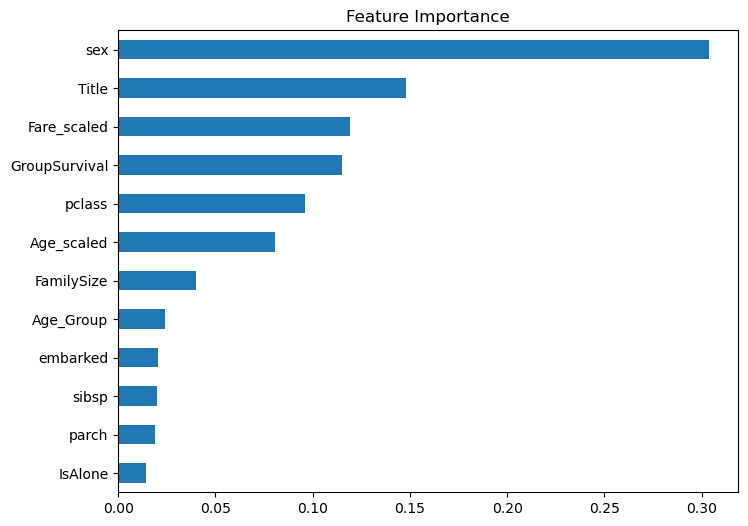

In [265]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance")
plt.show()

In [60]:
0.34, 16.336 -> 0
16.336, 32.252 -> 1
32.252, 48.168 -> 2
48.168, 64.084 -> 3
64.084, 80.0 -> 4
이 구간을 통해 이런식으로 만들어주겠다

SyntaxError: invalid syntax (97215175.py, line 1)

In [82]:
# for문을 통해서 0,1,2,3,4로 맵핑 시켜주자
for i in data_list:
    i.loc[i['Age'] <= 16, 'Age'] = 0
    i.loc[(i['Age'] > 16) & (i['Age'] <= 32), 'Age'] = 1
    i.loc[(i['Age'] > 32) & (i['Age'] <= 48), 'Age'] = 2
    i.loc[(i['Age'] > 48) & (i['Age'] <= 64), 'Age'] = 3
    i.loc[i['Age'] > 64, 'Age'] = 4

# agerange 제거
train.drop('agerange', axis=1, inplace=True)
train.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,1.0,1,0,A/5 21171,7.25,NaN,S


In [85]:
train['Name'].head(10)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: object

In [87]:
# title이라는 컬럼을 새로 만들어서 전처리 해보자
# [A-Za-z] : 대문자 또는 소문자 중에서 하나를 찾아
# + : 알파뱃 글자들이 여러 개 붙어 있는 단어를 찾아라
# \. : 글자 그대로의 점을 찾아라
train['title'] = train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
train['title'].value_counts()

title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

In [89]:
Mr          517
Miss        182
Mrs         125
Master       40
이 부분이 가장 많이 차지하므로 이거 왜 다른 것들은 other 라는 걸로 바꿔주겠다

SyntaxError: invalid syntax (3201190452.py, line 1)

In [91]:
for i in data_list:
    i['title'] = i['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    i['title'] = i['title'].replace(['Dr','Rev','Mlle','Major','Col','Countess',
                                    'Capt','Ms','Sir','Lady','Mme','Don','Jonkheer'], 'other')

# 카테고리화 시켜주고 수치로 바꿔주는 
    i['title_name'] = i['title'].astype('category').cat.codes

In [93]:
train.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,title,title_name
0,1,0,3,"Braund, Mr. Owen Harris",1,1.0,1,0,A/5 21171,7.25,NaN,S,Mr,2


In [95]:
# 이름별로 생존률을 확인
train[['title','Survived']].groupby(['title']).mean()

,Survived
title,
Master,0.575000
Miss,0.697802
Mr,0.156673
Mrs,0.792000
other,0.444444


In [97]:
# title / name 제거
train.drop(['Name','title'], axis=1, inplace=True)
test.drop(['Name','title'], axis=1, inplace=True)

In [99]:
test.head(1)

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,title_name
0,892,3,1,2.0,0,0,330911,7.8292,NaN,Q,3
